In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd


In [4]:
df = pd.read_csv('/content/drive/MyDrive/NLPData/songs.csv')

In [5]:
popular = df[df['popularity'] > 30]

In [14]:
#below .4 = not danceable
#above .6 = danceable

danceable = popular[popular['danceability'] > .6]
not_danceable = popular[popular['danceability'] < .4]

dance500 = danceable.sample(n=500, random_state=1)
not_dance500 = not_danceable.sample(n=500, random_state=1)

In [15]:
dancing1000v2 = pd.concat([dance500, not_dance500],axis=0)

In [16]:

len(dancing1000v2)


1000

In [17]:
for i in dancing1000v2['name']:
  print(i)

Tainted Love
Hakai
Mash
Alone on the Moon
Thank you
Perfect Strangers
Let Me Know
LOCO
Wonder Girl
You Know You Don't Mind
If Its You
Clench
You drive me crazy
Life Is A Honeymoon
Dance Monkey
Happy Pum Pum
I’m So Humble
Would That Make You Love Me?
Tangled
Too Experienced
Money Ain't a Thang (feat. JAY-Z)
One Jump Ahead
Be Good 2 Me
Body On Me ft. Chris Brown
Give Me Everything (feat. Nayer)
Shadows
Love Again
Blueberry Faygo
Hive
Banana Split For My Baby - Remastered
5'5 (feat. Latto)
It's All the Way Live
My World (Album Version (Explicit))
Hit Different
The Little Drummer Boy
Blem
heart attack
DnF (feat. Drake & Future)
Moving Targets
Get Outta My Dreams, Get Into My Car
The Drop Starts At 00:53
Quarter Milli (feat. Gucci Mane)
Dem Boyz
Cups - Movie Version
Jorja Interlude
You Are My High (Extended Version) - 2024 Remastered
What'chu Like (feat. Tyrese)
Changing Colours
Gemini
Falling
FANCY
Limelight
Hear My Train A Comin' (Acoustic)
Silverado Bench Seat
Mask 2 My Face
You Put The 

In [26]:
import matplotlib.pyplot as plt
import re
import numpy as np
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer


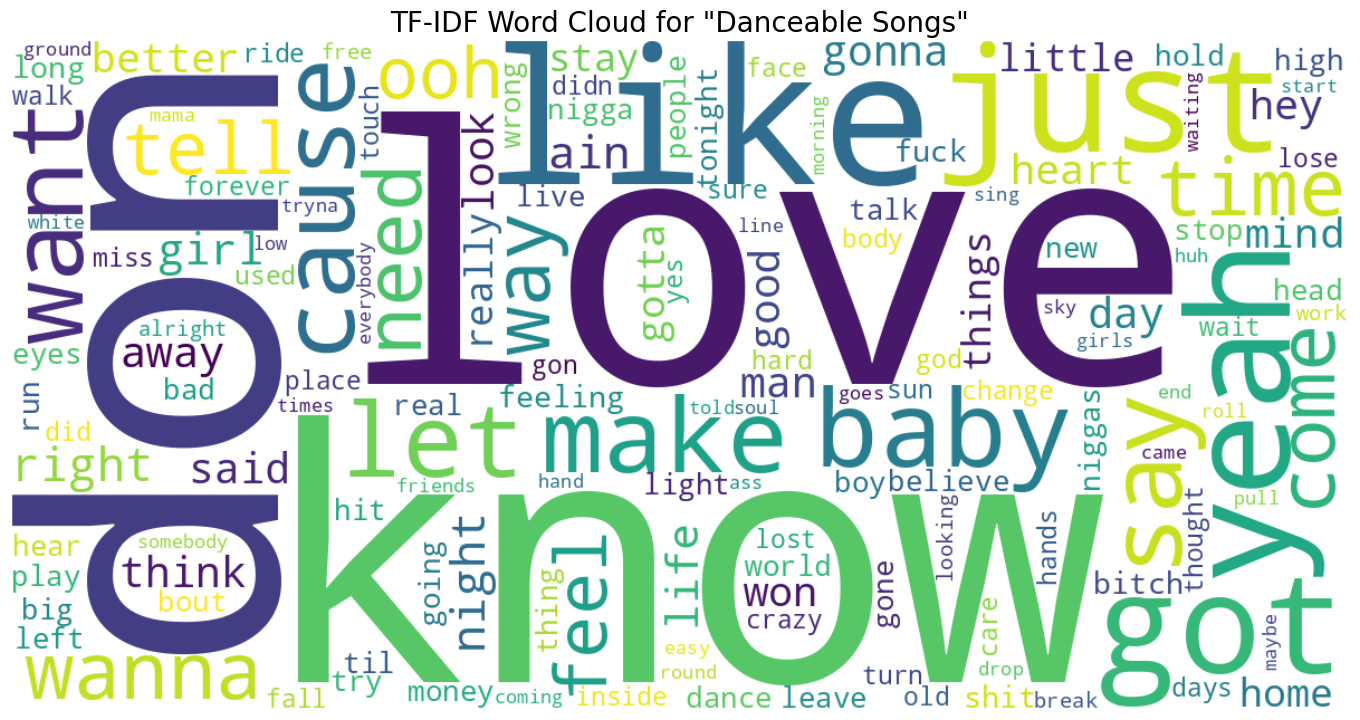

In [38]:
def plot_wordcloud(df, lyrics_col="lyrics"):
    df["lyrics"] = df["lyrics"].fillna("").str.replace(r"\\n", " ", regex=True)

    vectorizer = TfidfVectorizer(stop_words="english", sublinear_tf=True,
                              token_pattern=r"(?u)\b[a-zA-Z]{3,}\b")
    matrix = vectorizer.fit_transform(df['lyrics'].tolist())
    scores = np.asarray(matrix.sum(axis=0)).flatten()
    word_scores = dict(zip(vectorizer.get_feature_names_out(), scores))

    # Word cloud
    wc = WordCloud(width=1200, height=600, background_color="white",
                  colormap="viridis", max_words=150)
    wc.generate_from_frequencies(word_scores)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
    plt.title('TF-IDF Word Cloud for "Danceable Songs"', fontsize=20)
    plt.show()

plot_wordcloud(dance500)

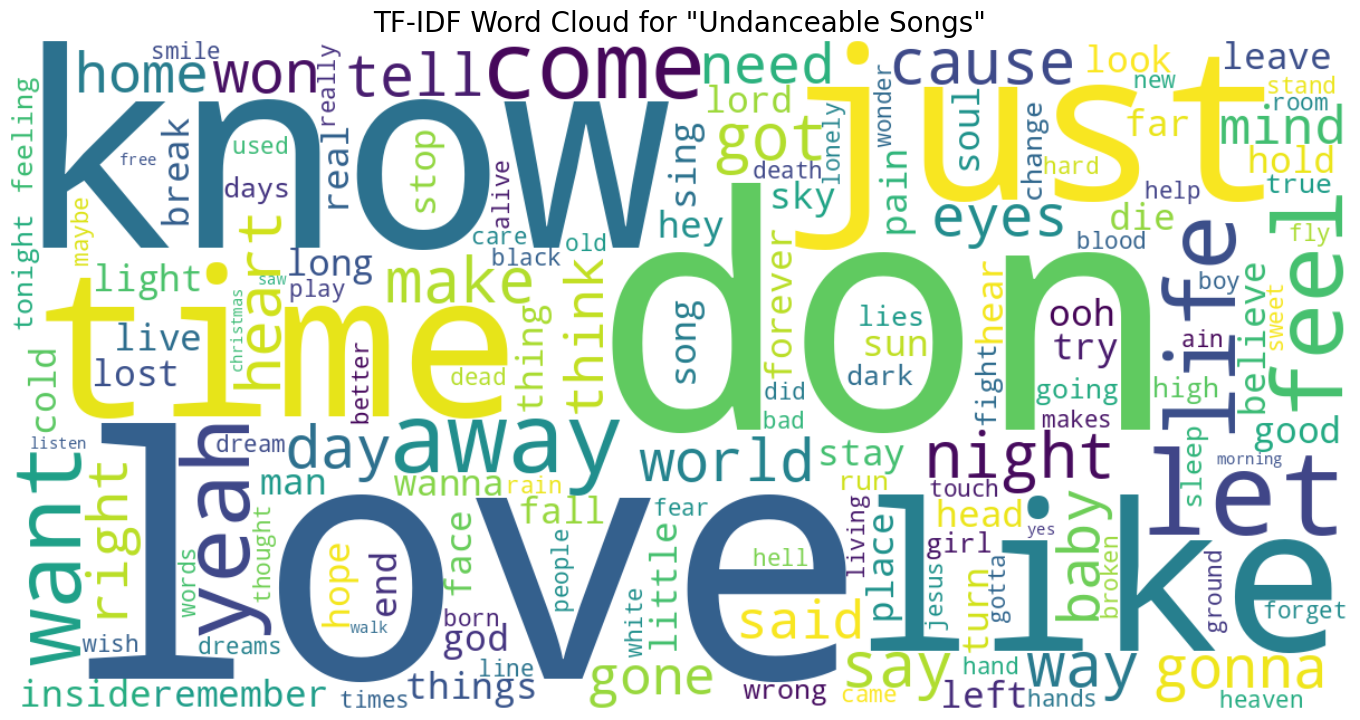

In [40]:
def plot_wordcloud(df, lyrics_col="lyrics"):
    df["lyrics"] = df["lyrics"].fillna("").str.replace(r"\\n", " ", regex=True)

    vectorizer = TfidfVectorizer(stop_words="english", sublinear_tf=True,
                              token_pattern=r"(?u)\b[a-zA-Z]{3,}\b")
    matrix = vectorizer.fit_transform(df['lyrics'].tolist())
    scores = np.asarray(matrix.sum(axis=0)).flatten()
    word_scores = dict(zip(vectorizer.get_feature_names_out(), scores))

    # Word cloud
    wc = WordCloud(width=1200, height=600, background_color="white",
                  colormap="viridis", max_words=150)
    wc.generate_from_frequencies(word_scores)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
    plt.title('TF-IDF Word Cloud for "Undanceable Songs"', fontsize=20)
    plt.show()

plot_wordcloud(not_dance500)

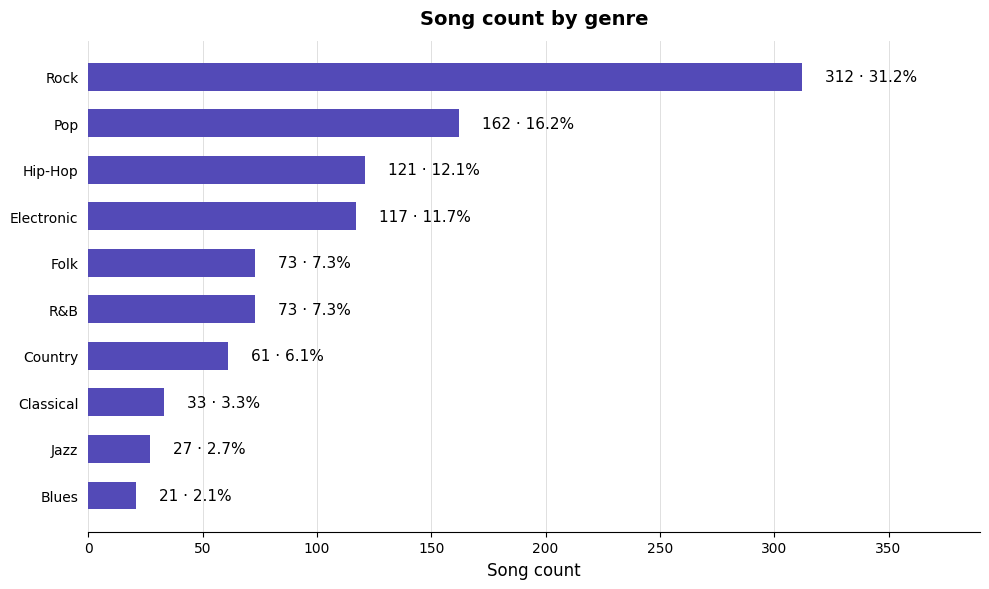

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# get counts, sorted descending
genre_counts = dancing1000v2['genre'].value_counts().sort_values(ascending=True)  # ascending=True so largest is on top

total = genre_counts.sum()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(genre_counts.index, genre_counts.values, color="#534AB7", height=0.6)

# inline value + percentage labels
for bar, val in zip(bars, genre_counts.values):
    pct = val / total * 100
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,} · {pct:.1f}%",
        va="center", ha="left", fontsize=11, color="black"
    )

ax.set_xlabel("Song count", fontsize=12)
ax.set_title("Song count by genre", fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.xaxis.grid(True, color="#e0e0e0", linewidth=0.7)
ax.set_axisbelow(True)
ax.tick_params(left=False)

# extra right margin so labels don't get clipped
ax.set_xlim(right=genre_counts.max() * 1.25)

plt.tight_layout()
plt.savefig("genre_counts.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
dancing1000v2.to_csv('/content/drive/MyDrive/NLPData/dancing1000v2.csv')

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


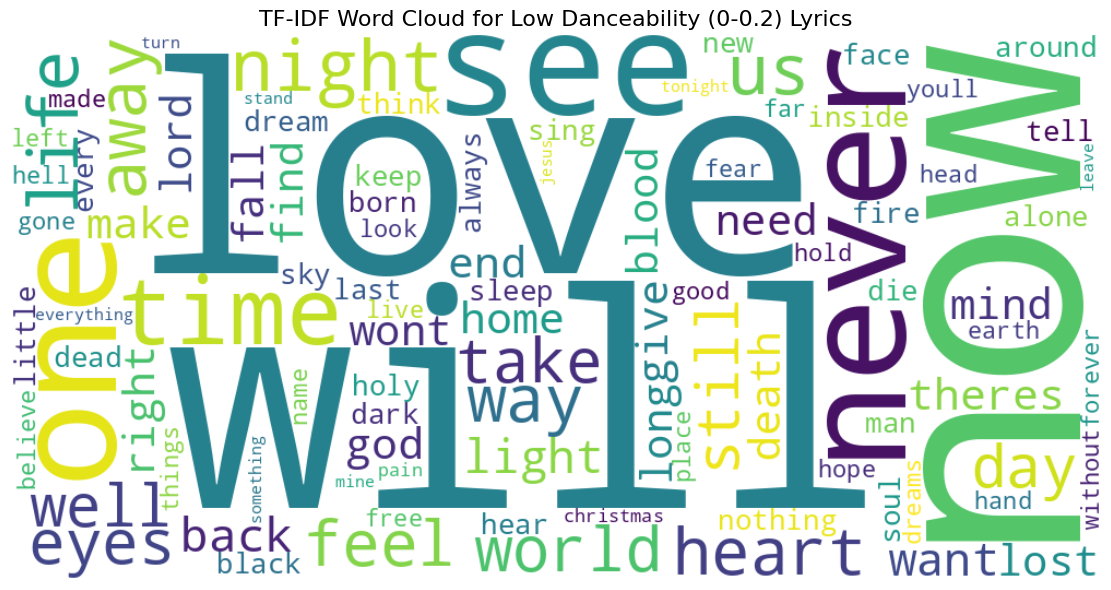

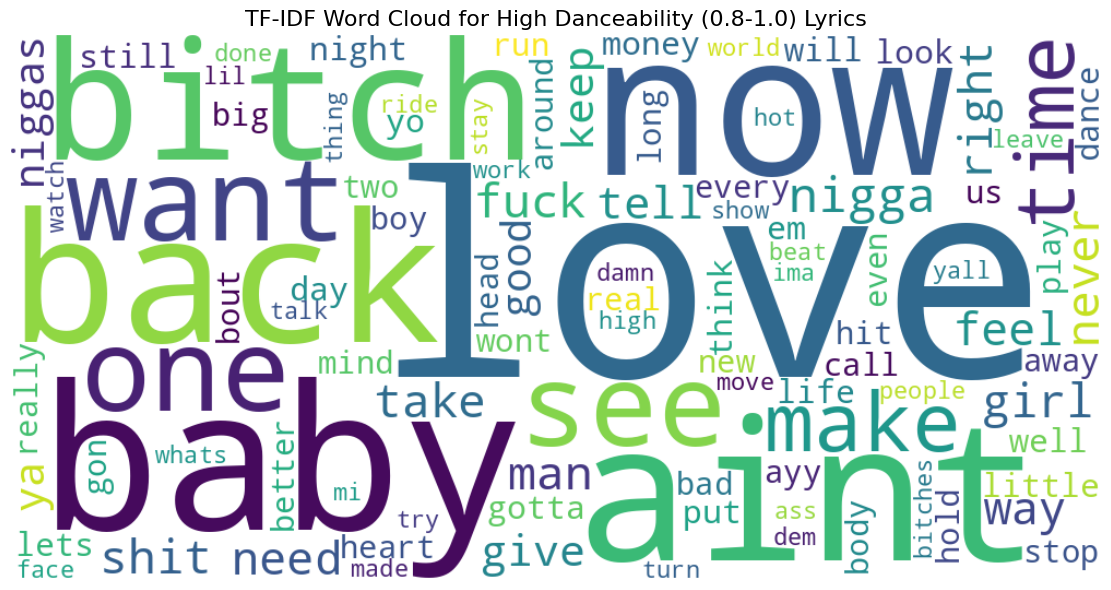

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

# LYRIC_STOPWORDS is already defined in a previous cell

def plot_tfidf_wordcloud(df, title, lyrics_col="lyrics"):
    # Ensure there are lyrics to process
    if df.empty or df[lyrics_col].isnull().all():
        print(f"No lyrics found for {title}. Skipping word cloud generation.")
        return

    # Combine all lyrics into a list for TF-IDF vectorizer
    lyrics_list = df[lyrics_col].fillna("").tolist()

    # Preprocess text for TF-IDF
    processed_lyrics = []
    for lyric in lyrics_list:
        lyric = lyric.lower()
        lyric = re.sub(r"\[.*?\]", "", lyric)  # strip [Chorus] etc.
        lyric = re.sub(r"[^a-z\s]", "", lyric)
        processed_lyrics.append(lyric)

    # Initialize TF-IDF Vectorizer
    # max_features limits the number of words, stop_words filters common words
    tfidf_vectorizer = TfidfVectorizer(max_features=100, stop_words=list(LYRIC_STOPWORDS))

    # Fit and transform the processed lyrics
    tfidf_matrix = tfidf_vectorizer.fit_transform(processed_lyrics)

    # Get feature names (words) and their corresponding TF-IDF scores
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # Sum TF-IDF scores for each word across all documents in the group to get overall importance
    word_tfidf_scores = {}
    for i, word in enumerate(feature_names):
        word_tfidf_scores[word] = tfidf_matrix[:, i].sum()

    # Generate WordCloud from frequencies (TF-IDF scores)
    wc = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        max_words=100, # Max words to display in the word cloud
        colormap="viridis",
        collocations=False, # Set to False to prevent combining frequently co-occurring words
    ).generate_from_frequencies(word_tfidf_scores)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"TF-IDF Word Cloud for {title} Lyrics", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"tfidf_wordcloud_{title.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Filter songs based on danceability
low_danceability_songs = popular[(popular['danceability'] >= 0) & (popular['danceability'] <= 0.2)].copy()
high_danceability_songs = popular[(popular['danceability'] >= 0.8) & (popular['danceability'] <= 1.0)].copy()

# Generate and plot TF-IDF word clouds for both categories
plot_tfidf_wordcloud(low_danceability_songs, "Low Danceability (0-0.2)")
plot_tfidf_wordcloud(high_danceability_songs, "High Danceability (0.8-1.0)")